In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [3]:
from google.colab import files

uploaded = files.upload()

Saving train.csv to train.csv


In [4]:
import os
print(os.listdir())

['.config', 'drive', 'train.csv', 'sample_data']


In [6]:
import pandas as pd

df = pd.read_csv('train.csv')

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
df.shape

(891, 12)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [9]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [10]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [11]:
df.drop(
    columns=['PassengerId', 'Name', 'Ticket', 'Cabin'],
    inplace=True
)

In [12]:
df['Age'] = df['Age'].fillna(
    df['Age'].median()
)

In [13]:
df['Embarked'] = df['Embarked'].fillna(
    df['Embarked'].mode()[0]
)

In [14]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

In [15]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


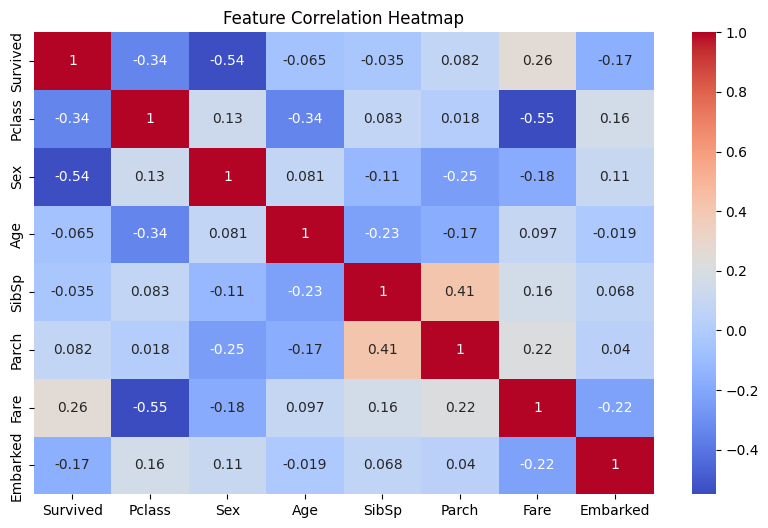

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Feature Correlation Heatmap')

plt.show()

Sex, Fare and Pclass show strong relationships with survival. These features are likely to be important predictors in the machine learning models.

In [17]:
X = df.drop('Survived', axis=1)

y = df['Survived']

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [20]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

In [21]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [22]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def evaluate_model(y_true, y_pred):

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    return [accuracy, precision, recall, f1]

In [24]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'KNN',
        'Random Forest'
    ],

    'Accuracy': [
        evaluate_model(y_test, lr_pred)[0],
        evaluate_model(y_test, knn_pred)[0],
        evaluate_model(y_test, rf_pred)[0]
    ],

    'Precision': [
        evaluate_model(y_test, lr_pred)[1],
        evaluate_model(y_test, knn_pred)[1],
        evaluate_model(y_test, rf_pred)[1]
    ],

    'Recall': [
        evaluate_model(y_test, lr_pred)[2],
        evaluate_model(y_test, knn_pred)[2],
        evaluate_model(y_test, rf_pred)[2]
    ],

    'F1 Score': [
        evaluate_model(y_test, lr_pred)[3],
        evaluate_model(y_test, knn_pred)[3],
        evaluate_model(y_test, rf_pred)[3]
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.810056,0.785714,0.743243,0.763889
1,KNN,0.703911,0.684211,0.527027,0.595420
2,Random Forest,0.821229,0.808824,0.743243,0.774648


In [25]:
results.sort_values(
    by='Accuracy',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.821229,0.808824,0.743243,0.774648
0,Logistic Regression,0.810056,0.785714,0.743243,0.763889
1,KNN,0.703911,0.684211,0.527027,0.595420


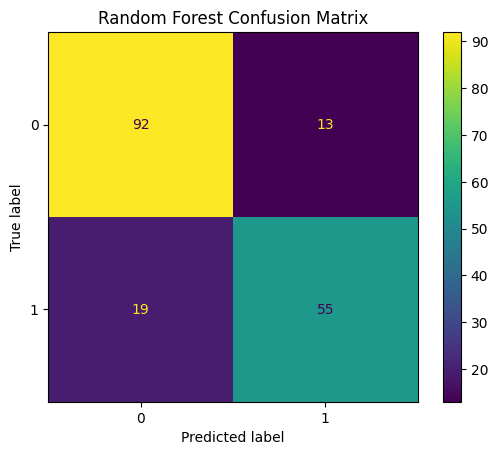

In [26]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title('Random Forest Confusion Matrix')

plt.show()

**Best Model Analysis**

Among the three models tested, Random Forest achieved the highest accuracy and overall performance.
Random Forest performed better because it can capture complex relationships between features and reduce overfitting through the use of multiple decision trees.
The confusion matrix shows that most passengers were classified correctly.
This makes Random Forest the most suitable model for predicting passenger survival in this dataset.

**Conclusion**

The Titanic dataset was preprocessed by handling missing values and encoding categorical variables.
Three machine learning algorithms were trained and evaluated: Logistic Regression, KNN, and Random Forest.
The models were compared using Accuracy, Precision, Recall, and F1 Score.
Random Forest achieved the best overall performance and was selected as the final model.
This project demonstrates the complete machine learning workflow from preprocessing and feature engineering to model evaluation and selection.